In [14]:
from math import exp

# 1d gaussian
a = 10
def U(x):
    return a * x**2

def dU(x):
    return 2*a*x

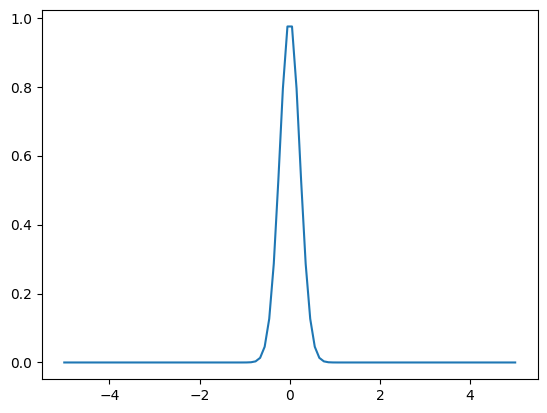

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# plot distribution
x = np.linspace(-5, 5, 100)
y = np.array([exp(-U(i)) for i in x])
plt.plot(x,y)

In [16]:
import torch
torch.randn(()).item()

0.530368983745575

In [21]:
from torch.distributions import Normal

stepsize = 0.1
x = -6

for _ in range(1):
    
    U_this  = U(x)
    dU_this = dU(x)

    mu = x - 0.5 * stepsize**2 * dU_this
    sigma = stepsize
    print("current:", x, U_this, dU_this)
    print("forw transition:", mu, sigma)
    
    distr = Normal(mu, sigma)
    x1 = distr.sample().item()
    q_this = distr.log_prob(torch.tensor(x1)).item()

    U_tmp  = U(x1)
    dU_tmp = dU(x1)

    mu = x1 - 0.5 * stepsize**2 * dU_tmp
    sigma = stepsize
    distr = Normal(mu, sigma)
    q_tmp = distr.log_prob(torch.tensor(x)).item()

    print("propose:", x1, U_tmp, dU_tmp)
    print('back', mu, sigma)

    print('qq:', q_this, q_tmp)
        print(U_this, U_tmp, q_tmp, q_this)

    arej = exp(U_this-U_tmp) * exp(q_tmp) / (exp(q_this) + 1e-8)
    print("A:", arej)

current: -6 360 -120
forw transition: -5.4 0.1
propose: -5.46364164352417 298.5138000885149 -109.2728328704834
back -4.917277479171753 0.1
qq: 1.1811343431472778 -57.230770111083984
360 298.5138000885149 -57.230770111083984 1.1811343431472778
A: 21.63463394987991


In [22]:
# 2D gaussian

In [60]:
from math import exp

# 1d gaussian
a = 10
def U(x):
    return a * (x**2).sum(axis=-1)

def dU(x):
    return 2*a*x

torch.Size([400, 400, 2])


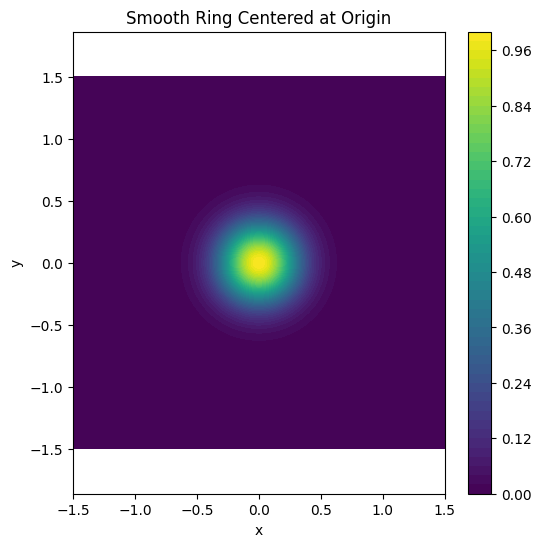

In [61]:
# Create a meshgrid for plotting
x = np.linspace(-1.5, 1.5, 400)
y = np.linspace(-1.5, 1.5, 400)
X, Y = np.meshgrid(x, y)
p = torch.concat((torch.tensor(X).unsqueeze(axis=-1), torch.tensor(Y).unsqueeze(axis=-1)), axis=2)
print(p.shape)
Z = (-U(p)).exp().numpy()
# Z = U(p).numpy()
# Z = dU(p)[...,1].numpy()

# Plot the function
plt.figure(figsize=(6,6))
plt.contourf(X, Y, Z, 50, cmap='viridis')
plt.colorbar()
plt.title('Smooth Ring Centered at Origin')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

In [62]:
from torch.distributions import Normal

stepsize = 0.1
x = torch.tensor([3.0, 0])


U_this  = U(x)
dU_this = dU(x)
    
mu = x - 0.5 * stepsize**2 * dU_this
sigma = stepsize
print("current:", x, U_this, dU_this)
print("forw transition:", mu, sigma)

current: tensor([3., 0.]) tensor(90.) tensor([60.,  0.])
forw transition: tensor([2.7000, 0.0000]) 0.1


In [63]:
distr = Normal(mu, sigma)
x1 = distr.sample()
q_this = distr.log_prob(x1).sum(axis=-1)

U_tmp  = U(x1)
dU_tmp = dU(x1)

In [64]:
# reverse transition
mu = x1 - 0.5 * stepsize**2 * dU_tmp
sigma = stepsize
distr = Normal(mu, sigma)
q_tmp = distr.log_prob(x).sum(axis=-1)

In [65]:
print(U_this, U_tmp, q_tmp, q_this)

tensor(90.) tensor(71.3103) tensor(-15.1081) tensor(2.6470)


In [66]:
arej = exp(U_this-U_tmp) * exp(q_tmp) / (exp(q_this) + 1e-8)

In [67]:
arej

2.545895803566361

In [ ]:
from torch.distributions import Normal

stepsize = 0.1
x = torch.tensor([6.0, 0])

for _ in range(1):
    
    U_this  = U(x)
    dU_this = dU(x)

    mu = x - 0.5 * stepsize**2 * dU_this
    sigma = stepsize
    print("current:", x, U_this, dU_this)
    print("forw transition:", mu, sigma)
    
    distr = Normal(mu, sigma)
    x1 = distr.sample().item()
    q_this = distr.log_prob(torch.tensor(x1)).item()

    U_tmp  = U(x1)
    dU_tmp = dU(x1)

    mu = x1 - 0.5 * stepsize**2 * dU_tmp
    sigma = stepsize
    distr = Normal(mu, sigma)
    q_tmp = distr.log_prob(torch.tensor(x)).item()

    print("propose:", x1, U_tmp, dU_tmp)
    print('back', mu, sigma)

    print('qq:', q_this, q_tmp)
    print(U_this, U_tmp, q_tmp, q_this)

    arej = exp(U_this-U_tmp) * exp(q_tmp) / (exp(q_this) + 1e-8)
    print("A:", arej)